In [3]:
import pandas as pd

# Assuming the dataset is in /tmp/ and named 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
try:
    df = pd.read_csv('/tmp/WA_Fn-UseC_-Telco-Customer-Churn.csv')
    print("Dataset loaded successfully!")
    print("\nFirst 5 rows of the dataset:")
    display(df.head())
    print("\nDataset Info:")
    df.info()
except FileNotFoundError:
    print("Error: 'WA_Fn-UseC_-Telco-Customer-Churn.csv' not found in /tmp/. Please ensure the file is there or adjust the path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully!

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

### Phase 1: Problem Definition
**Problem:** Predict whether a customer will churn (binary classification).
**Input Features:** Customer demographics, account information, services used.
**Output Label:** 'Churn' (Yes/No)

### Phase 2: Dataset Collection
Dataset loaded successfully in the previous step.

### Phase 3: Data Preprocessing
Next, we will preprocess the data by removing unnecessary columns, handling missing values, and converting categorical features to numerical ones. I will also convert 'TotalCharges' to a numeric type, as it's often imported as an object due to some rows containing spaces.

In [13]:
# Phase 7 (revisited): Prediction on test data using the best tuned model

# Make predictions on the test set using the best_rf_model
y_pred_tuned = best_rf_model.predict(X_test)
y_pred_proba_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Predictions on the test set generated successfully using the best tuned model.")

Predictions on the test set generated successfully using the best tuned model.


Accuracy (Tuned Model): 0.8062
Precision (Tuned Model): 0.6712
Recall (Tuned Model): 0.5294
F1-Score (Tuned Model): 0.5919
ROC AUC Score (Tuned Model): 0.8441


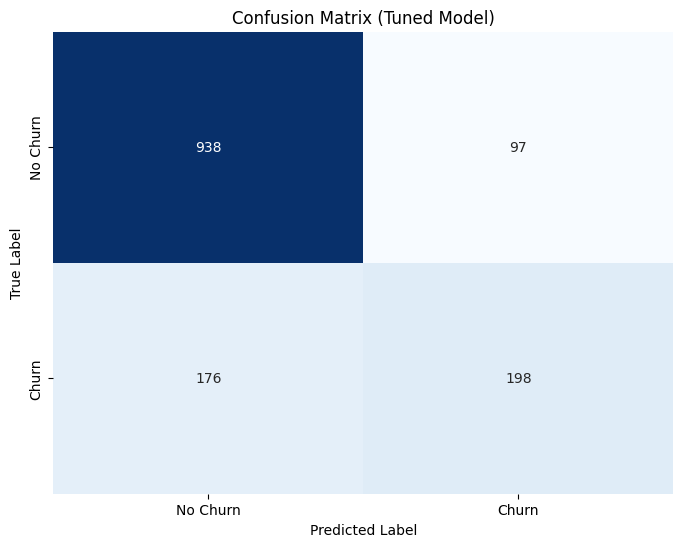

Model evaluation complete for the tuned model. Confusion Matrix displayed.


In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 8 (revisited): Model Evaluation for the best tuned model

# Calculate evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
roc_auc_tuned = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"Accuracy (Tuned Model): {accuracy_tuned:.4f}")
print(f"Precision (Tuned Model): {precision_tuned:.4f}")
print(f"Recall (Tuned Model): {recall_tuned:.4f}")
print(f"F1-Score (Tuned Model): {f1_tuned:.4f}")
print(f"ROC AUC Score (Tuned Model): {roc_auc_tuned:.4f}")

# Display Confusion Matrix for the tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Tuned Model)')
plt.show()

print("Model evaluation complete for the tuned model. Confusion Matrix displayed.")

In [12]:
from sklearn.model_selection import GridSearchCV

# Phase 6: Hyperparameter Tuning

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of trees in the forest
    'max_depth': [10, 20, 30, None],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10]   # Minimum number of samples required to split an internal node
}

# Initialize GridSearchCV
# 'scoring' can be adjusted based on the primary evaluation metric (e.g., 'recall', 'f1')
# For churn prediction, 'recall' or 'f1' might be more appropriate given potential class imbalance
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Optimize for ROC AUC score
    n_jobs=-1, # Use all available CPU cores
    verbose=2 # Display detailed progress
)

print("Starting GridSearchCV for hyperparameter tuning...")

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV complete.")

# Print the best parameters and best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best ROC AUC score found: {grid_search.best_score_:.4f}")

# Store the best model
best_rf_model = grid_search.best_estimator_
print("Best Random Forest model stored as 'best_rf_model'.")

Starting GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
GridSearchCV complete.
Best parameters found: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Best ROC AUC score found: 0.8433
Best Random Forest model stored as 'best_rf_model'.


Accuracy: 0.7864
Precision: 0.6237
Recall: 0.4920
F1-Score: 0.5501
ROC AUC Score: 0.8251


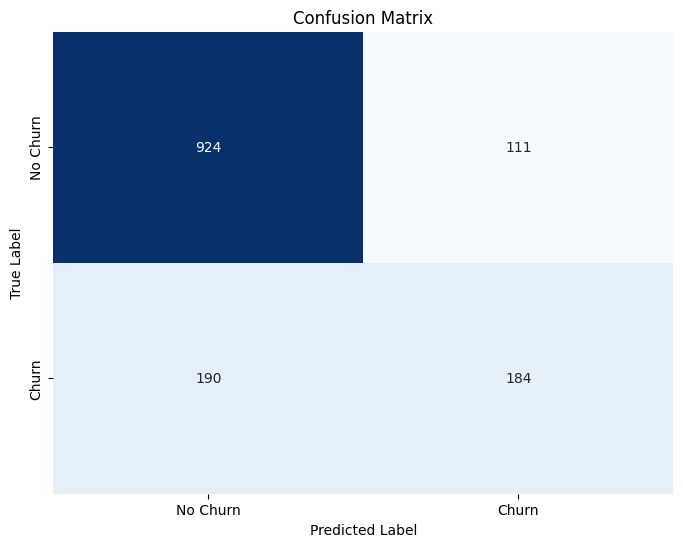

Model evaluation complete. Confusion Matrix displayed.


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Phase 8: Model Evaluation

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print("Model evaluation complete. Confusion Matrix displayed.")

In [10]:
# Phase 7: Prediction on test data

# Make predictions on the test set
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Predictions on the test set generated successfully.")

Predictions on the test set generated successfully.


In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# Using default parameters for now, will tune later in Phase 6
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully on the training data.")

Random Forest model trained successfully on the training data.


In [8]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nDistribution of Churn in training set:")
print(y_train.value_counts(normalize=True))

print("\nDistribution of Churn in testing set:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (5634, 30)
Shape of X_test: (1409, 30)
Shape of y_train: (5634,)
Shape of y_test: (1409,)

Distribution of Churn in training set:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Distribution of Churn in testing set:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [7]:
# Convert 'Churn' column to numerical (Yes=1, No=0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Get a list of categorical columns (excluding 'Churn' as it's already numerical)
categorical_cols = df.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("\nData types after categorical encoding:")
df.info()

print("\nFirst 5 rows after encoding:")
display(df.head())


Data types after categorical encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7043 non-null   float64
 4   Churn                                  7043 non-null   int64  
 5   gender_Male                            7043 non-null   bool   
 6   Partner_Yes                            7043 non-null   bool   
 7   Dependents_Yes                         7043 non-null   bool   
 8   PhoneService_Yes                       7043 non-null   bool   
 9   MultipleLines_No phone service         7043 non-null   bool   
 10  MultipleLines_Yes               

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [6]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the 'customerID' column if it exists, as it is not needed for the model
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("Dropped 'customerID' column.")
else:
    print("'customerID' column not found, already dropped or not present.")

# Handle missing values in 'TotalCharges' by filling with the median
# Checking for missing values after conversion
if df['TotalCharges'].isnull().sum() > 0:
    median_total_charges = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(median_total_charges)
    print(f"Filled {df['TotalCharges'].isnull().sum()} missing values in 'TotalCharges' with the median: {median_total_charges}")
else:
    print("No missing values found in 'TotalCharges' after conversion.")

print("\nData types after initial preprocessing:")
df.info()

print("\nFirst 5 rows after preprocessing TotalCharges and customerID:")
display(df.head())

'customerID' column not found, already dropped or not present.
No missing values found in 'TotalCharges' after conversion.

Data types after initial preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
!unzip -o /content/archive.zip -d /tmp/

print("Archive unzipped. Please check if 'Telco-Customer-Churn.csv' is now in /tmp/.")
print("After unzipping, please re-run the cell above to load the dataset.")

Archive:  /content/archive.zip
  inflating: /tmp/WA_Fn-UseC_-Telco-Customer-Churn.csv  
Archive unzipped. Please check if 'Telco-Customer-Churn.csv' is now in /tmp/.
After unzipping, please re-run the cell above to load the dataset.
